# Begin

In [1]:
import logging
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle

from datetime import datetime

from utils import get_file_list, load_processed_bhav
from plots import *

logging.basicConfig()
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

# Inverted IV

In [2]:
data_reserve = "./inverting_iv/artefacts/"
files = get_file_list(data_reserve, glob="*-allbhav-iv.csv")
df = pd.concat([load_processed_bhav(f) for f in files])

df = (
    df
    .reset_index()
    .sort_values(["date", "expiry_date", "strike"])
    .set_index("date")
)

logger.info(f"{datetime.now()}: Loaded processed Bhavcopies: {df.shape}.")

INFO:utils:2026-09-16 21:51:57.843262: Found 2 files.
INFO:__main__:2026-09-16 21:51:57.928379: Loaded processed Bhavcopies: (10076, 11).


## Implied Volatility smiles per day
For specifically the October 2019 expiries.

INFO:plots:2026-09-16 21:51:58.801611: Filtering expiries to lie within 2019-10-03 and 2019-10-31.
INFO:plots:2026-09-16 21:51:58.805202: Plotting daily implied volatility curves for 5 expiries...
INFO:plots:2026-09-16 21:51:58.919093: Expiry date 2019-10-24 00:00:00 has no data.
INFO:plots:2026-09-16 21:51:58.945007: Expiry date 2019-10-24 00:00:00 has no data.
INFO:plots:2026-09-16 21:51:58.963251: Expiry date 2019-10-24 00:00:00 has no data.
INFO:plots:2026-09-16 21:51:59.512739: Plot generated.


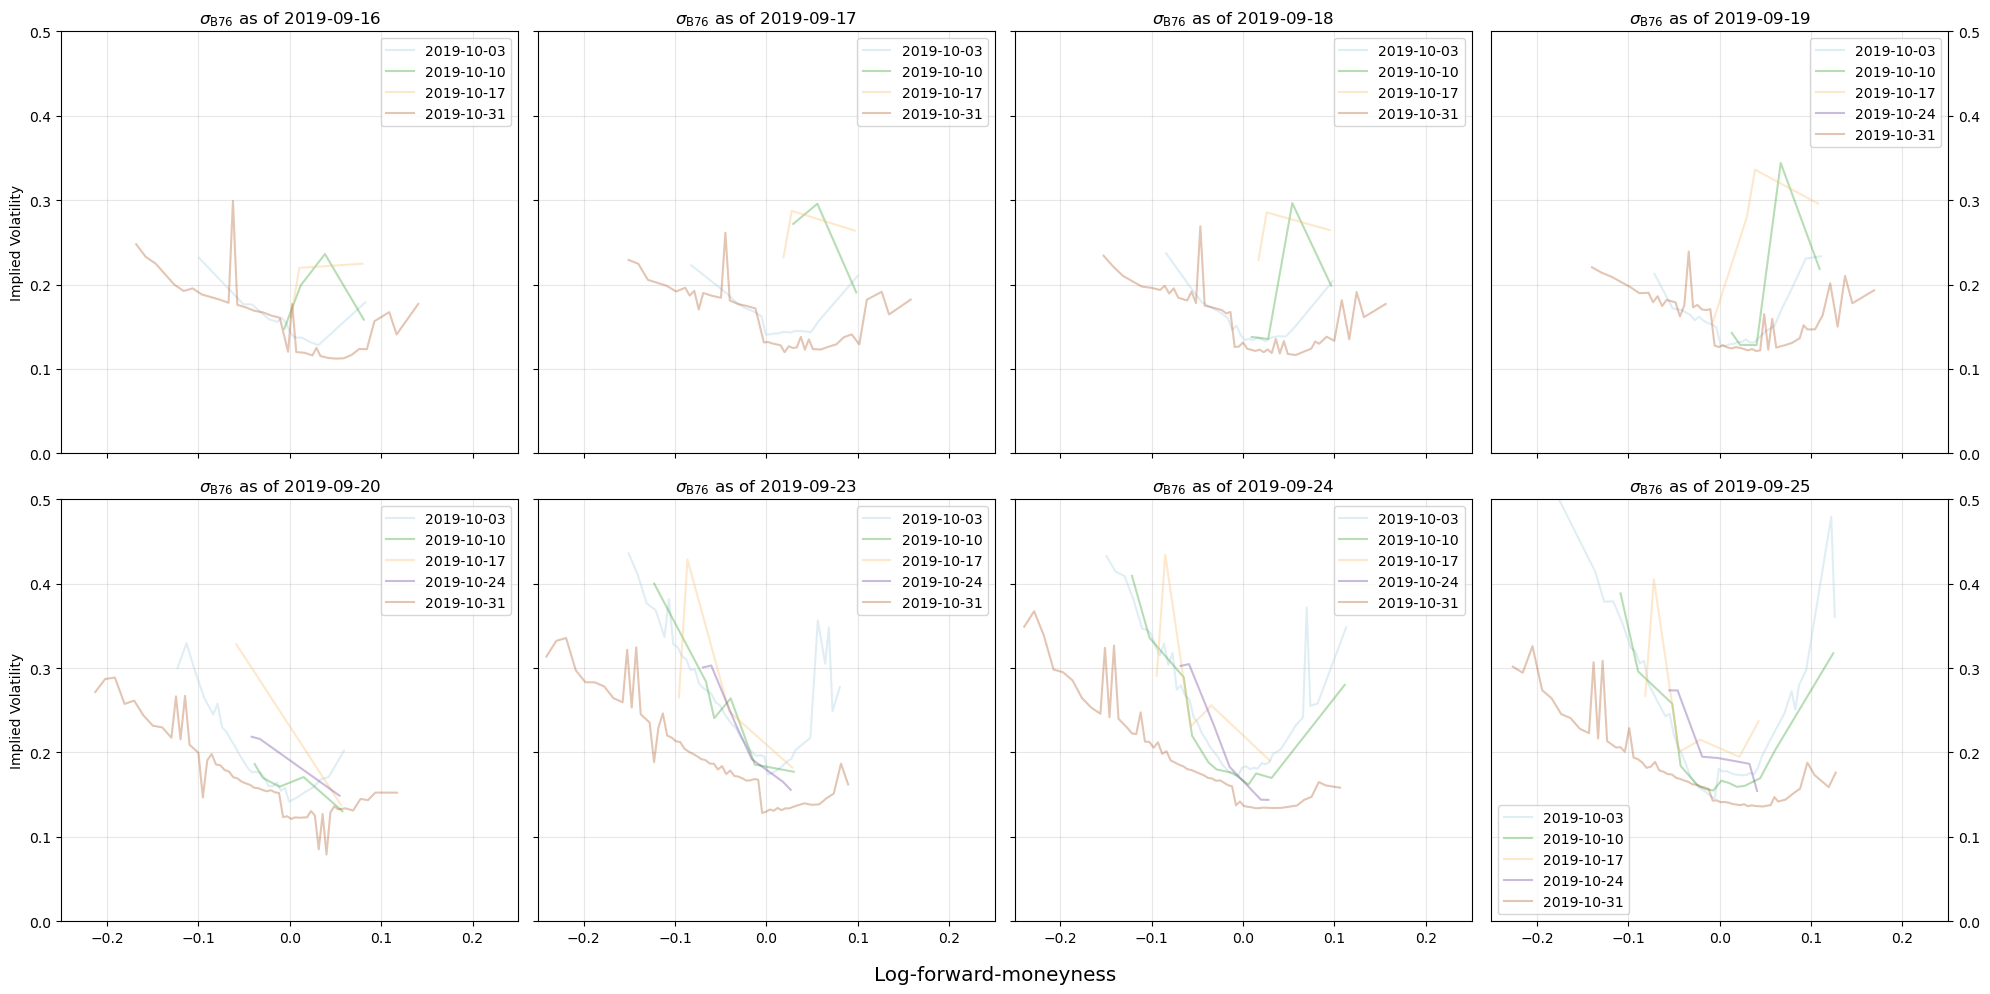

In [3]:
plot_daily_smiles(
    df,
    if_var       = False,
    start        = "2019-09-16",
    end          = "2019-09-25",
    expiry_start = "2019-10-03",
    expiry_end   = "2019-10-31",
)

plt.show()

## Total Implied Variance smiles per day
For specifically the October 2019 expiries.

INFO:plots:2026-09-16 21:52:01.173549: Filtering expiries to lie within 2019-10-03 and 2019-10-31.
INFO:plots:2026-09-16 21:52:01.177590: Plotting daily total implied variance curves for 5 expiries...
INFO:plots:2026-09-16 21:52:01.270204: Expiry date 2019-10-24 00:00:00 has no data.
INFO:plots:2026-09-16 21:52:01.290708: Expiry date 2019-10-24 00:00:00 has no data.
INFO:plots:2026-09-16 21:52:01.304731: Expiry date 2019-10-24 00:00:00 has no data.
INFO:plots:2026-09-16 21:52:01.838756: Plot generated.


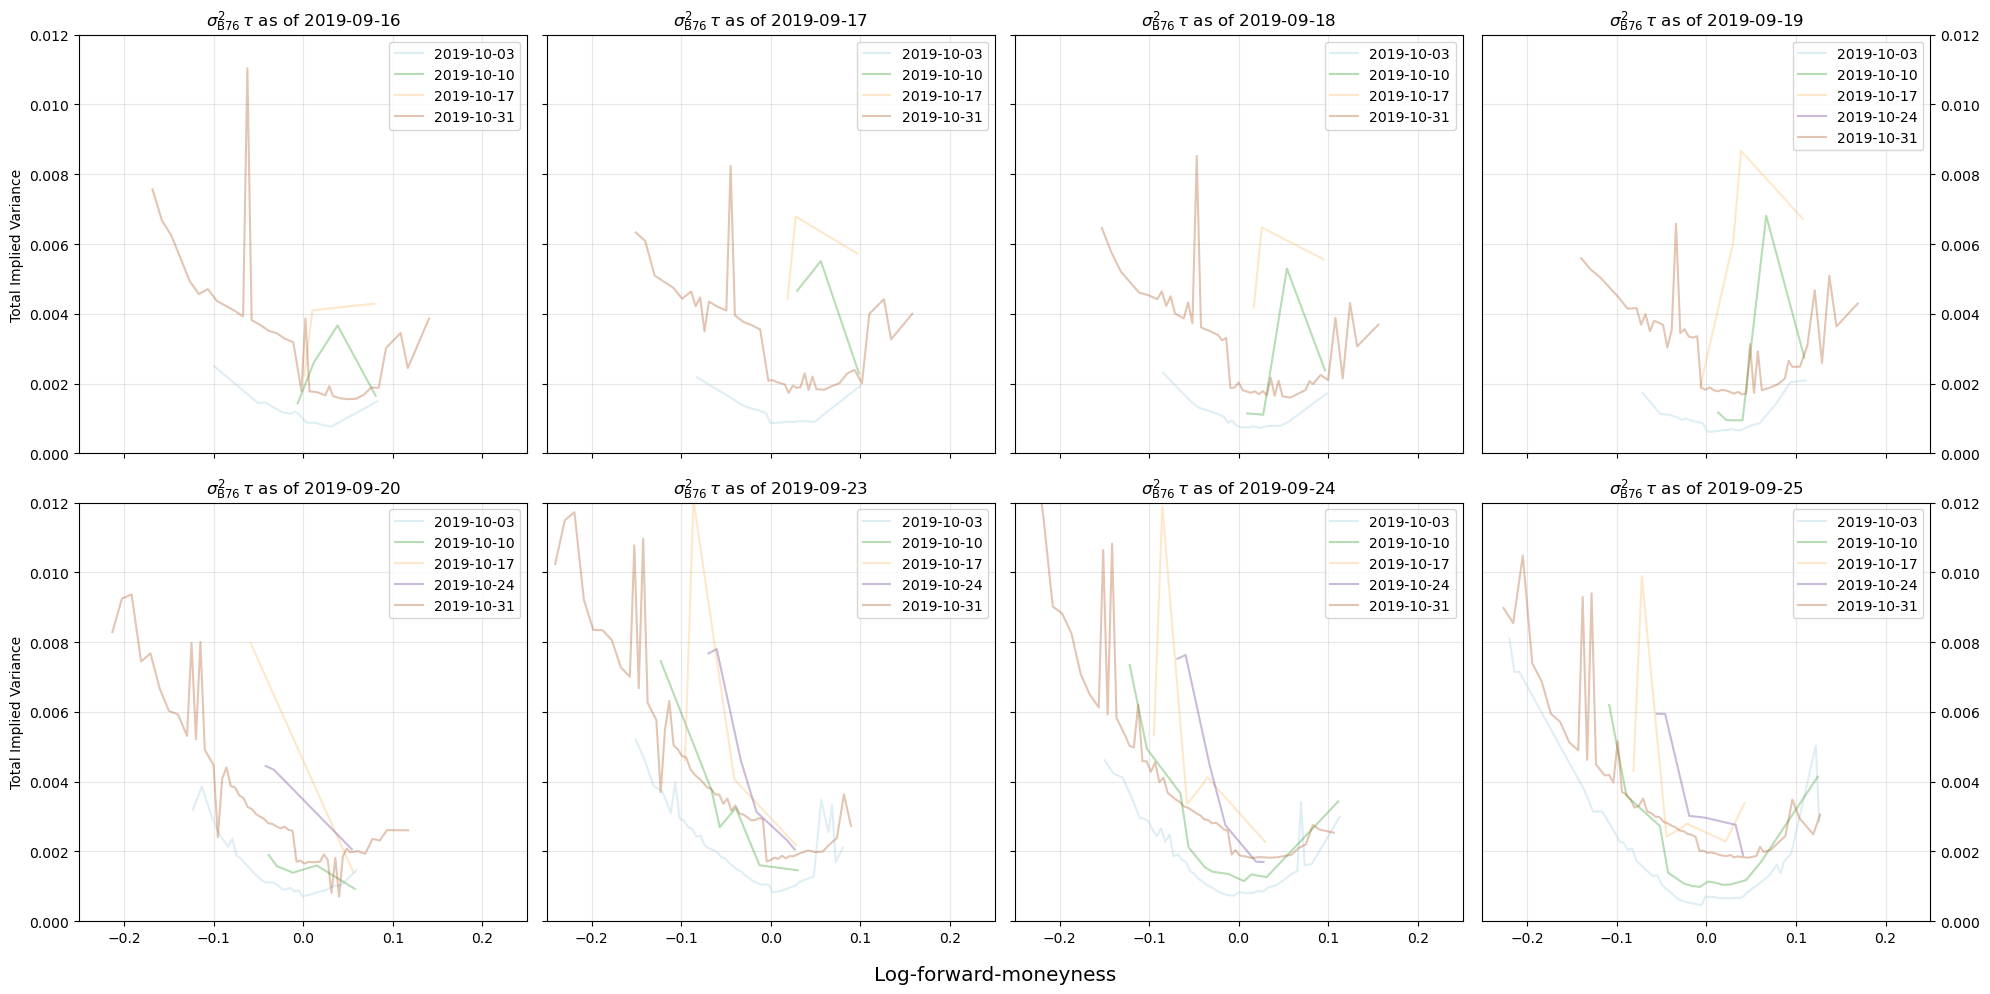

In [4]:
plot_daily_smiles(
    df,
    if_var       = True,
    start        = "2019-09-16",
    end          = "2019-09-25",
    expiry_start = "2019-10-03",
    expiry_end   = "2019-10-31",
)

plt.show()

# SSVI

In [5]:
# apparently, using `np.save()` and `np.load()` for dictionaries loads the dict
# as a 1D array. Jeez.
ssvi_artefact = "./ssvi/artefacts/2026-09-16_20-09-45_ssvi_fitted_params.pkl"

with open(ssvi_artefact, "rb") as f:
    ssvi_params = pickle.load(f)

## SSVI fits

INFO:plots:2026-09-16 21:52:06.313735: Filtering expiries to lie within 2019-10-03 and 2019-10-31.
INFO:plots:2026-09-16 21:52:06.318679: Plotting for 6 days and 5 expiries.
INFO:plots:2026-09-16 21:52:08.600210: Plot generated.


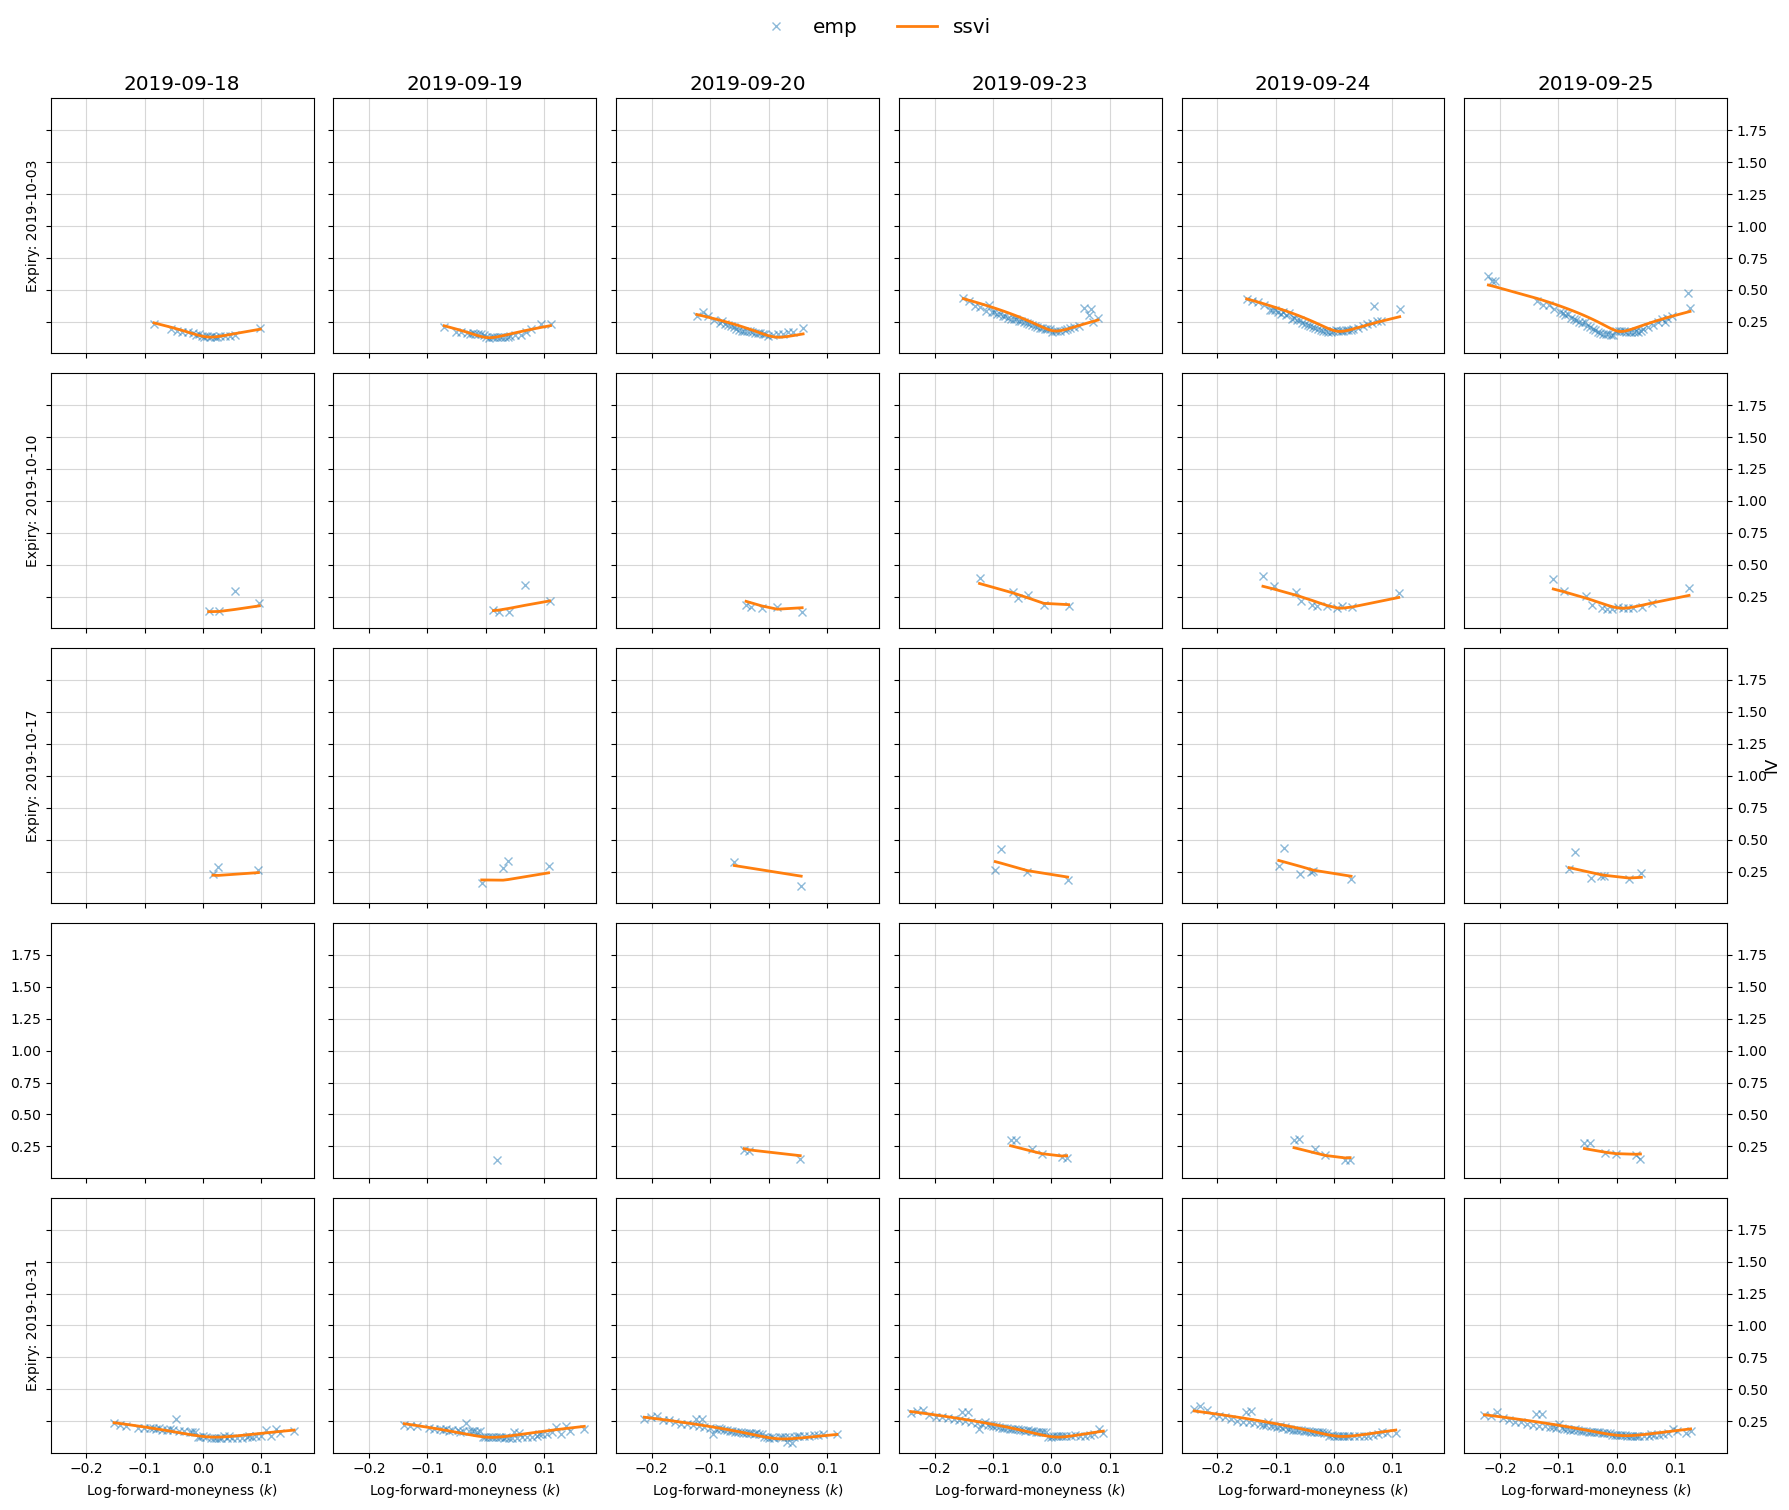

In [6]:
plot_ssvi_curves(
    ssvi_params  = ssvi_params,
    df_otm       = df,
    start        = "2019-09-18",
    end          = "2019-09-25",
    expiry_start = "2019-10-03",
    expiry_end   = "2019-10-31",
)

plt.show()

## SSVI fitted parameters

In [25]:
from scipy.stats import norm

def get_option_delta(
        K: pd.Series,
        iv: pd.Series,
        t_diff: pd.Series
    ) -> pd.Series | np.ndarray:
    """
    Computes the Delta (Greek) of a given option using log-forward-moneyness.

    Parameters:
    `K`: pd.Series:
        Series of options log-forward-moneyness.

    `iv`: pd.Series:
        Model-implied volatilities of a set of options.

    `t_diff`: pd.Series:
        Time to expiry, in years, of a set of options.
    """
    numer = K + (0.5*iv**2)*t_diff
    denom = iv*np.sqrt(t_diff)

    d1 = numer/denom

    delta = norm.cdf(d1)
    logger.info(f"{datetime.now()}: Computed option Delta(s).")
    return delta


def compute_risk_rev(
        ln_money: pd.Series,
        iv: pd.Series,
        tau: pd.Series,
        Delta: float=0.25,
    ) -> float:
    """
    Computes the Risk Reversal (RR) of a set of options. Risk Reversal is:
    $$ RR(x) = iv_{x Delta}^{CE} - iv_{x Delta}^{PE} $$

    Parameters:
    `ln_money`: pd.Series:
        Series of log-forward-moneyness for a set of corresponding options.

    `iv`: pd.Series:
        Model-implied volatilities of a set of options.

    `tau`:  pd.Series:
        Time to expiry, in years, of a set of options.

    `Delta`: pd.Series:
        The Delta to compute the RR at. Default=0.25, or the 25 Delta RR.

    Returns a float, which is the RR of a given option.

    Note: the parameters (except `Delta`) may be vectors, but the returned value
    is a float. This is because RR is only computed from the two options at a
    specific Delta, but the entire IV curve is needed to select options at that
    particular Delta.
    """
    # recall that \Delta=0.50 is at the money (ATM)
    deltas = get_option_delta(K=ln_money, iv=iv, t_diff=tau)

    iv_c = np.interp(Delta, deltas, iv)
    iv_p = np.interp(1-Delta, deltas, iv)
    return iv_c - iv_p

In [26]:
for (dt, data) in ssvi_params.items():
    _e = data["expiry_date"]
    _k = data["moneyness"]
    _s = data["ssvi_smile"]
    _t = data["time_to_exp"]

    last_expiry = np.unique(_e)[-1]
    mask = _e == last_expiry

    rr = compute_risk_rev(_k[mask], _s[mask], _t[mask])
    print(rr)

INFO:__main__:2026-09-16 21:44:53.766193: Computed option Delta(s).
INFO:__main__:2026-09-16 21:44:53.769372: Computed option Delta(s).
INFO:__main__:2026-09-16 21:44:53.770774: Computed option Delta(s).
INFO:__main__:2026-09-16 21:44:53.772272: Computed option Delta(s).
INFO:__main__:2026-09-16 21:44:53.773716: Computed option Delta(s).
INFO:__main__:2026-09-16 21:44:53.774932: Computed option Delta(s).
INFO:__main__:2026-09-16 21:44:53.776352: Computed option Delta(s).
INFO:__main__:2026-09-16 21:44:53.777469: Computed option Delta(s).
INFO:__main__:2026-09-16 21:44:53.778709: Computed option Delta(s).
INFO:__main__:2026-09-16 21:44:53.779937: Computed option Delta(s).
INFO:__main__:2026-09-16 21:44:53.781214: Computed option Delta(s).
INFO:__main__:2026-09-16 21:44:53.782475: Computed option Delta(s).
INFO:__main__:2026-09-16 21:44:53.783793: Computed option Delta(s).
INFO:__main__:2026-09-16 21:44:53.787806: Computed option Delta(s).
INFO:__main__:2026-09-16 21:44:53.789754: Comput

0.036188021334196185
0.04116774221580588
0.03912741610153933
0.042573818799286026
0.04138552996131438
0.038479855237621666
0.030516798275854407
0.03916971861401748
0.03225905665116263
0.03224136603257036
0.03212195499609932
0.02268502022700203
0.0431509033674245
0.03453984503824212
0.03923748757237533
0.028913450084444098
0.03585136854280477
0.030981603237092675
0.028681342656155073
0.027744272849997892
0.02565323733697028
0.019253093741229854


In [17]:
mask = df["expiry_date"].between("2019-10-03", "2019-10-31", inclusive="both")
_ = df.loc[mask]
expiries = sorted([str(i) for i in _["expiry_date"].unique().date])
risk_reversals = {}

for dt, data in ssvi_params.items():
    # need this to compute time to expiry, and subsequently delta for RR
    ddiff = pd.to_datetime(data["expiry_date"]) - pd.Timestamp(dt)
    print(len(ddiff))

    _ = pd.DataFrame({
        "ssvi"       : data["ssvi_smile"],
        'K'          : data["moneyness"],
        "expiry_date": data["expiry_date"],
        "iv"         : data["market_iv"],
        "tau"        : ddiff.total_seconds()/(60*60*24*365)
    })

    for exp in expiries:
        mask = _["expiry_date"].eq(exp)
        subdf = _.loc[mask].set_index('K').drop(columns="expiry_date")

        if exp == expiries[-1]:
            rr_svi = compute_risk_rev(
                ln_money = subdf.index,
                iv       = subdf["ssvi"],
                tau      = subdf["tau"],
            )

            risk_reversals[dt] = rr_svi

36
36
37
37
40
46
48
52
55
64
71
83
92
115
125
135
153
166
177
189
138
166


INFO:plots:2026-09-16 21:52:15.353114: Computing 25 Risk Reversals...
INFO:ssvi.metrics:2026-09-16 21:52:15.356544: Computed option Delta(s).
INFO:ssvi.metrics:2026-09-16 21:52:15.358055: Computed option Delta(s).
INFO:ssvi.metrics:2026-09-16 21:52:15.359124: Computed option Delta(s).
INFO:ssvi.metrics:2026-09-16 21:52:15.361440: Computed option Delta(s).
INFO:ssvi.metrics:2026-09-16 21:52:15.362481: Computed option Delta(s).
INFO:ssvi.metrics:2026-09-16 21:52:15.363721: Computed option Delta(s).
INFO:ssvi.metrics:2026-09-16 21:52:15.364642: Computed option Delta(s).
INFO:ssvi.metrics:2026-09-16 21:52:15.366024: Computed option Delta(s).
INFO:ssvi.metrics:2026-09-16 21:52:15.367122: Computed option Delta(s).
INFO:ssvi.metrics:2026-09-16 21:52:15.369435: Computed option Delta(s).
INFO:ssvi.metrics:2026-09-16 21:52:15.370566: Computed option Delta(s).
INFO:ssvi.metrics:2026-09-16 21:52:15.371949: Computed option Delta(s).
INFO:ssvi.metrics:2026-09-16 21:52:15.373358: Computed option Delt

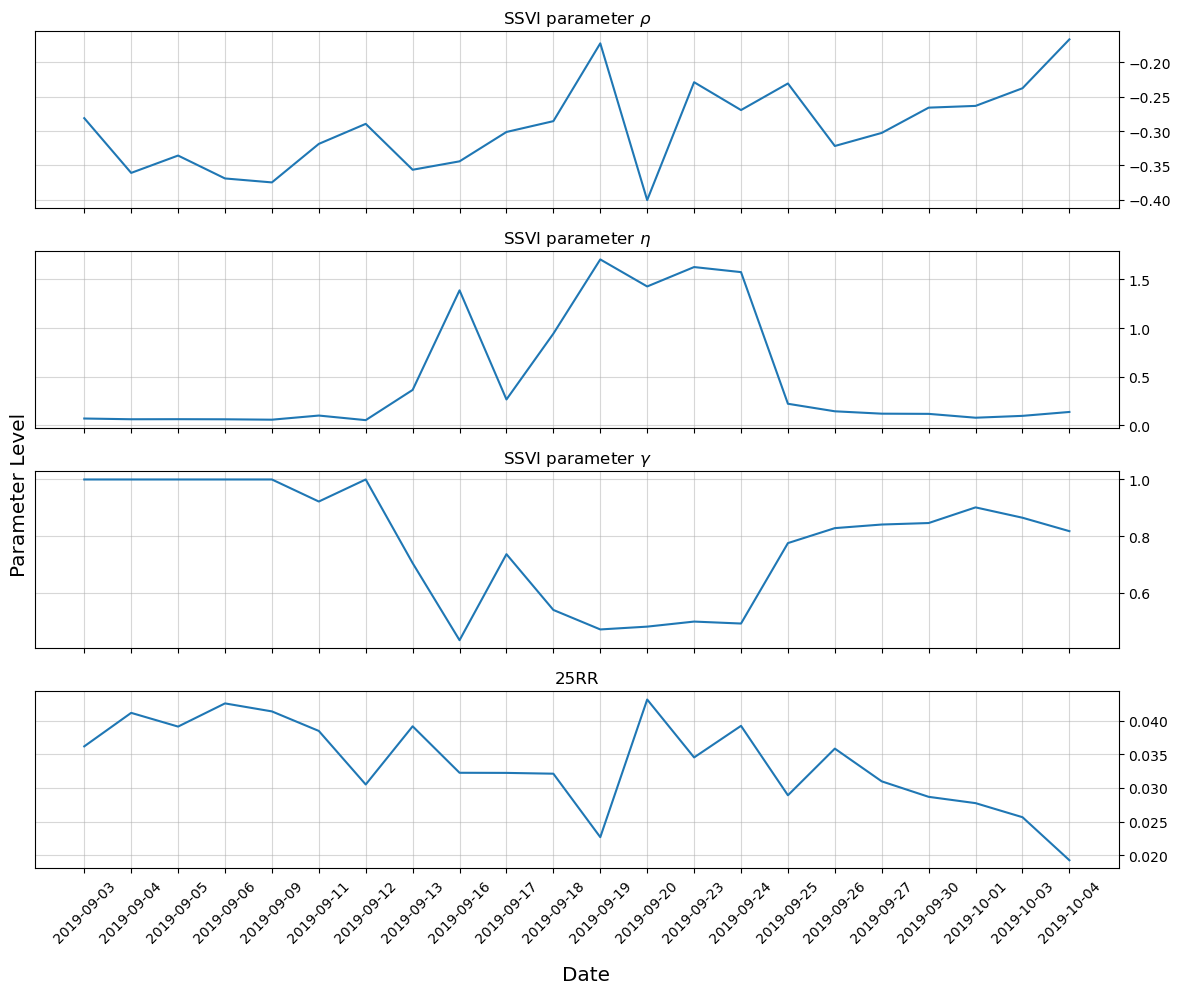

In [7]:
plot_ssvi_parameters(ssvi_params, rr_Delta=0.25)
plt.show()

## SSVI surfaces

INFO:plots:2026-09-16 21:52:54.153635: Plotting SSVI surfaces...
INFO:plots:2026-09-16 21:52:54.301183: Beginning interpolation...
INFO:plots:2026-09-16 21:52:54.686457: Plot generated.


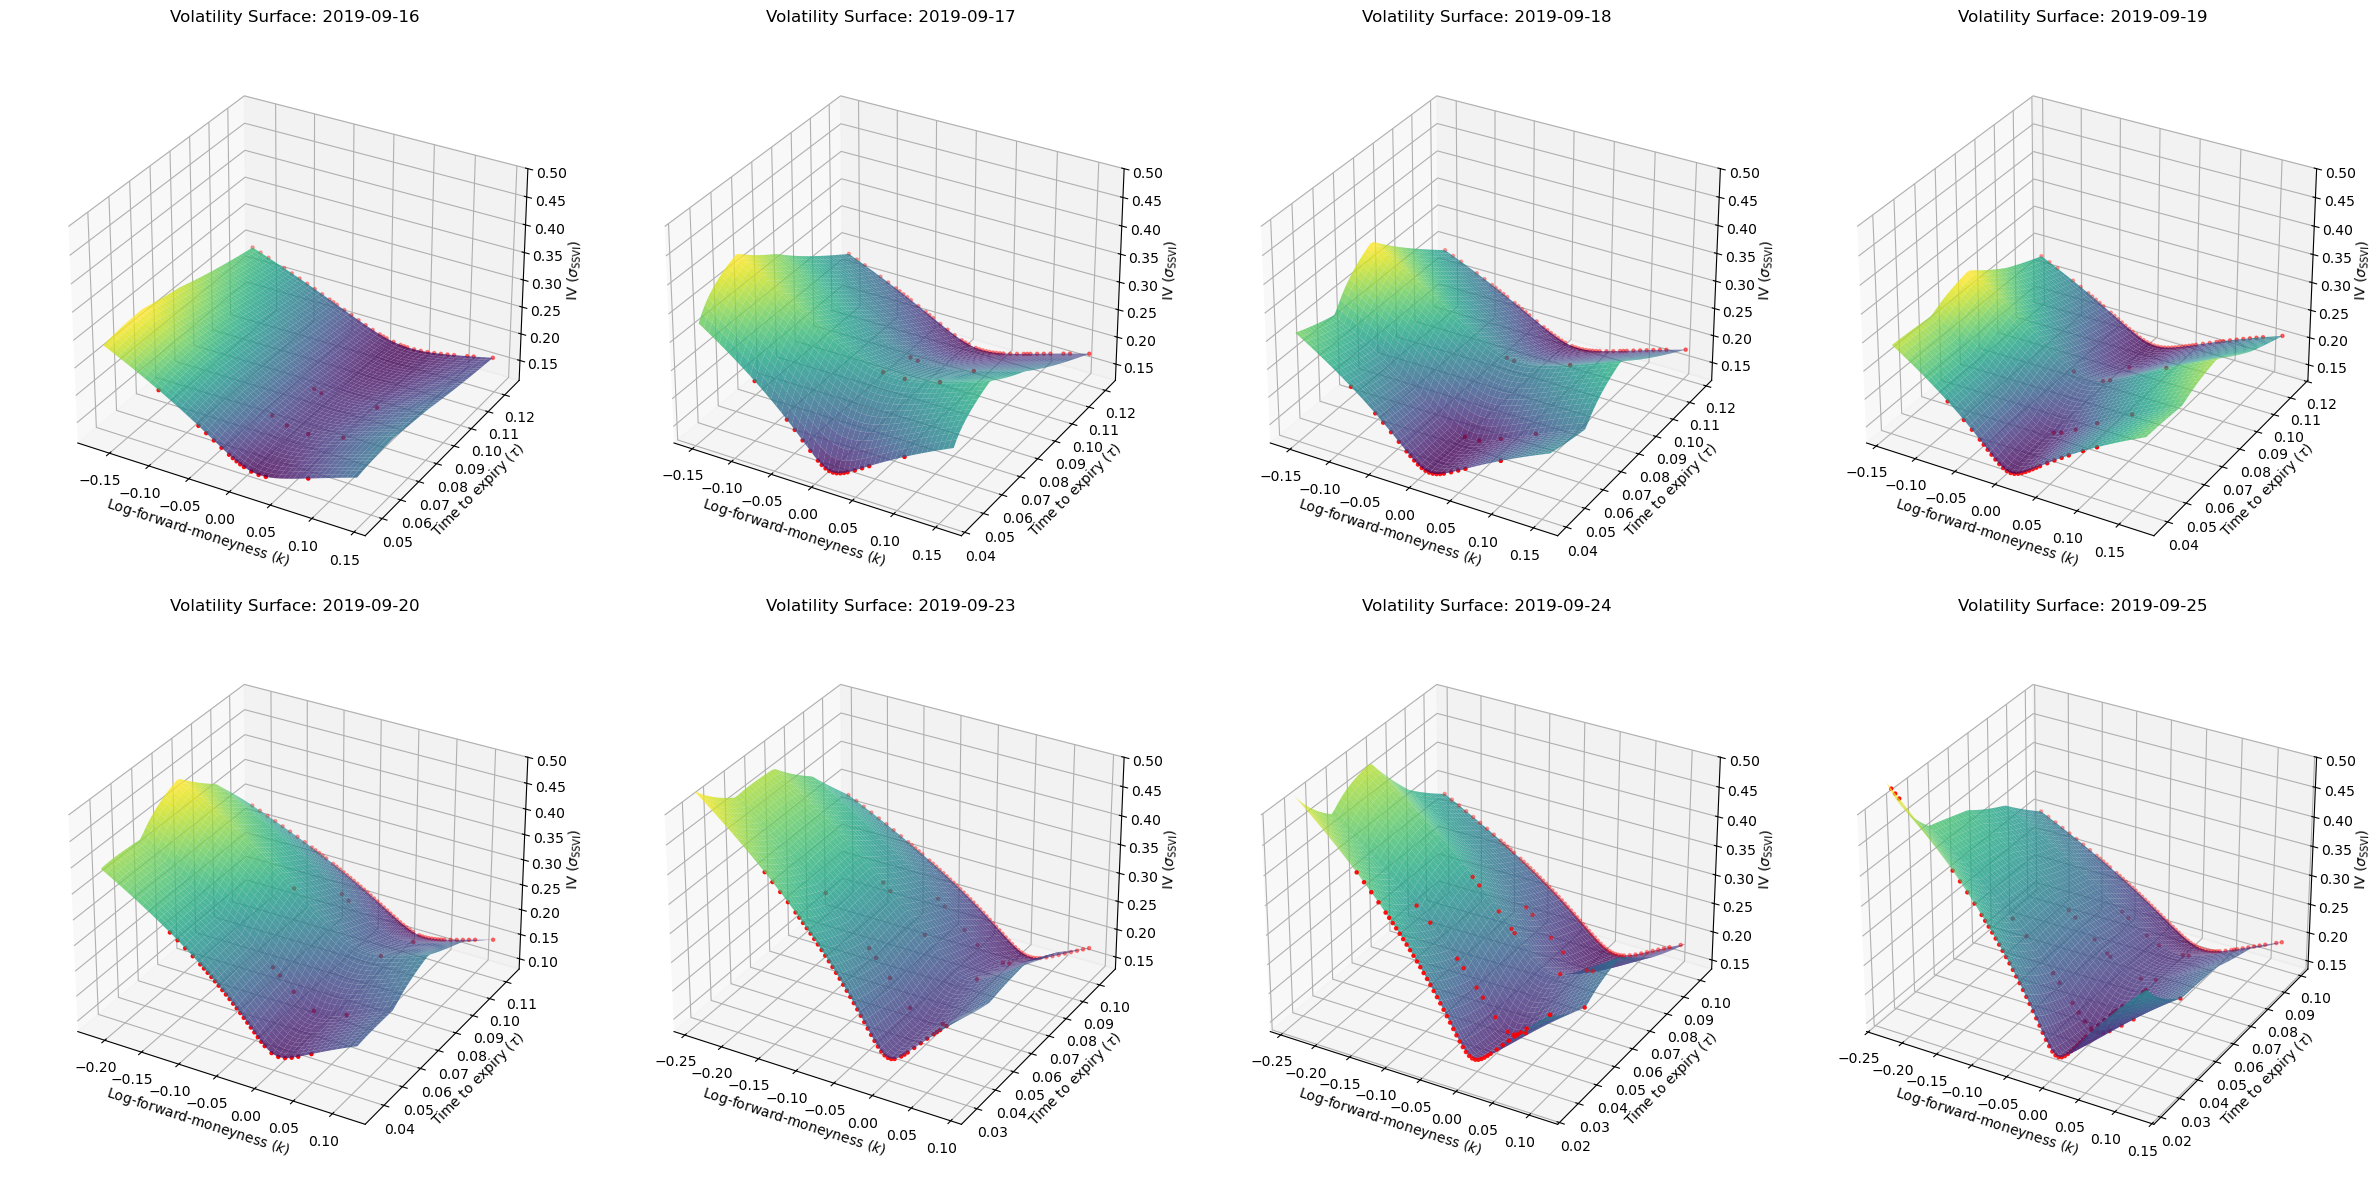

In [8]:
plot_ssvi_interp_surfaces(
    ssvi_params,
    start = "2019-09-16",
    end   = "2019-09-25"
)

plt.show()